In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE
from sklearn.pipeline import Pipeline

%matplotlib inline

In [2]:
# Principal Component Analysis (PCA)

# Exercise 1: Breast Cancer

In [13]:
from sklearn.datasets import load_breast_cancer

breast_cancer_data = load_breast_cancer()
breast_cancer_df = pd.DataFrame(breast_cancer_data.data, columns=breast_cancer_data.feature_names)
breast_cancer_df['target'] = breast_cancer_data.target

In [14]:
breast_cancer_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [15]:
breast_cancer_df.head(5)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [16]:
breast_cancer_df['target'] = pd.Categorical.from_codes(
    breast_cancer_df['target'],
    ['benign', 'malignant']
)

In [17]:
breast_cancer_df_corr = breast_cancer_df.corr(numeric_only=True)

<Axes: >

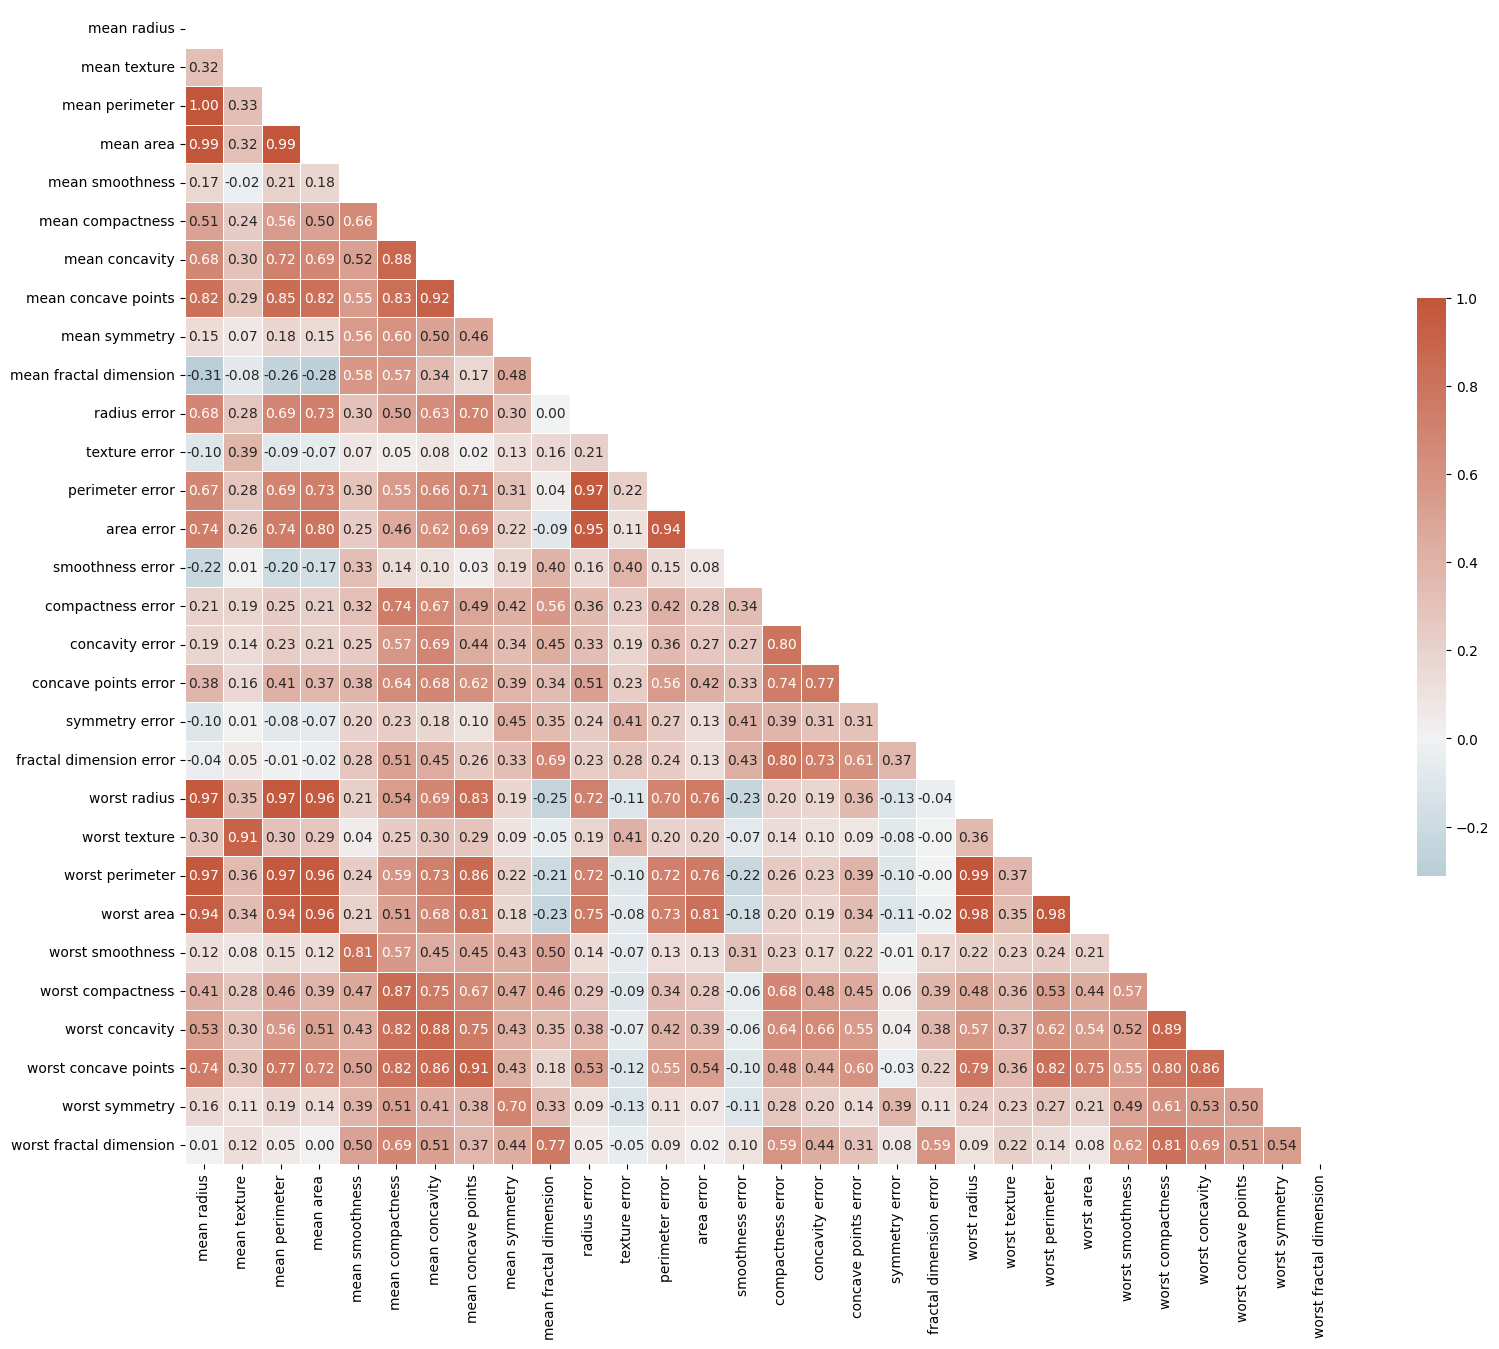

In [18]:
plt.figure(figsize=(20, 15))

mask = np.triu(np.ones_like(breast_cancer_df_corr, dtype=bool))

cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(breast_cancer_df_corr, annot=True, mask=mask, cmap=cmap, vmax=1, center=0, square=True, linewidths=.5, cbar_kws={"shrink": .5}, fmt=".2f")

In [19]:
# Na podstawie powyższej macierzy korelacji widać, że wiele cech jest liniowo-skorelowana, co oznacza, że przed użyciem np. regresji liniowej, odpowiednie cechy powinny zostać usunięte.

In [20]:
breast_cancer_X = breast_cancer_df.drop(columns='target')
breast_cancer_y = breast_cancer_df['target']

In [21]:
breast_cancer_pca_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=2))
])

breast_cancer_X_transformed = breast_cancer_pca_pipeline.fit_transform(breast_cancer_X)

breast_cancer_df_transformed = pd.DataFrame(breast_cancer_X_transformed, columns=['PC1', 'PC2'])
breast_cancer_df_transformed = pd.concat([breast_cancer_df_transformed, breast_cancer_y], axis=1)

In [22]:
breast_cancer_df_transformed['target'].cat.categories

Index(['benign', 'malignant'], dtype='object')

In [23]:
def visualize_pca(
    df: pd.DataFrame,
    pc1: str = "PC1",
    pc2: str = "PC2",
    target_col: str = "target",
    title: str = "PCA 2D visualization"
):

    fig, ax = plt.subplots(figsize=(8, 8))

    ax.set_xlabel("PC1", fontsize=12)
    ax.set_ylabel("PC2", fontsize=12)
    ax.set_title(title, fontsize=14)

    targets = df[target_col].cat.categories

    cmap = mpl.colormaps["tab10"]

    for i, target in enumerate(targets):
        mask = df[target_col] == target

        ax.scatter(
            df.loc[mask, pc1],
            df.loc[mask, pc2],
            color=cmap(i),
            s=40,
            label=str(target)
        )
    #

    ax.legend()
    ax.grid(True)

    plt.tight_layout()
    plt.show()

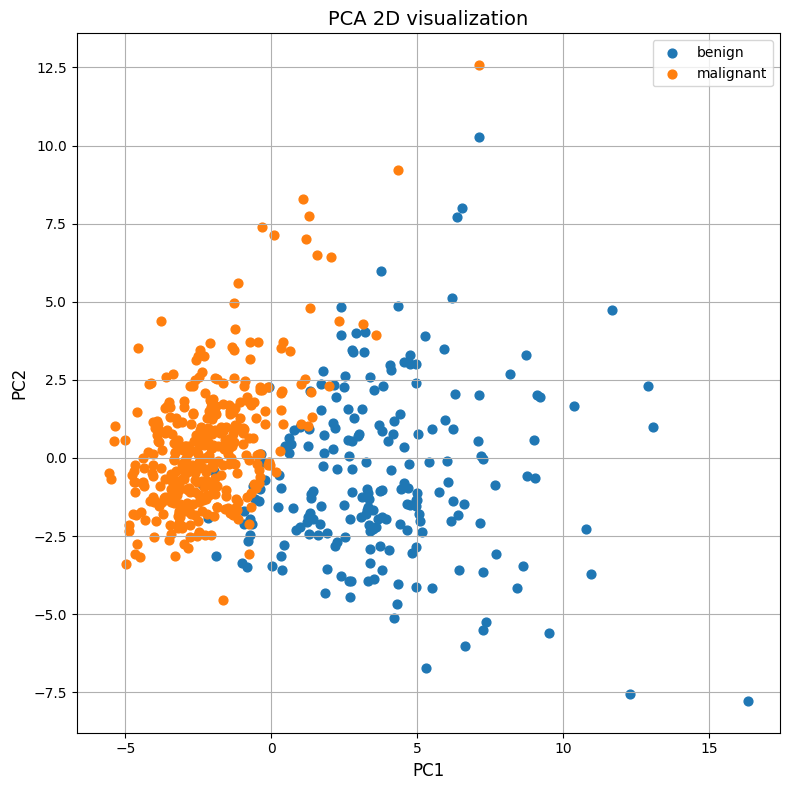

In [24]:
visualize_pca(breast_cancer_df_transformed)

In [25]:
breast_cancer_pca = breast_cancer_pca_pipeline.named_steps['pca']
breast_cancer_pca.explained_variance_ratio_

array([0.44272026, 0.18971182])

In [26]:
# Dodając do siebie otrzymane wariancje dostajemy około 0.63, więc nasze dwa komponenty zawierają około 63% informacji. Do samej wizualizacji 2D jest to w porządku,
# ale jako krok w procesie inżynierii cech, ten wynik jest dość mały. Należy zwiększyć liczbę komponentów.

In [27]:
breast_cancer_pca_pipeline.set_params(pca__n_components=15)
breast_cancer_X_transformed = breast_cancer_pca_pipeline.fit_transform(breast_cancer_X)

breast_cancer_df_transformed = pd.DataFrame(breast_cancer_X_transformed)
breast_cancer_df_transformed = pd.concat([breast_cancer_df_transformed, breast_cancer_y], axis=1)

In [28]:
breast_cancer_pca = breast_cancer_pca_pipeline.named_steps['pca']

explained_variance_full = breast_cancer_pca.explained_variance_ratio_
cumulative_variance_full = np.cumsum(explained_variance_full)

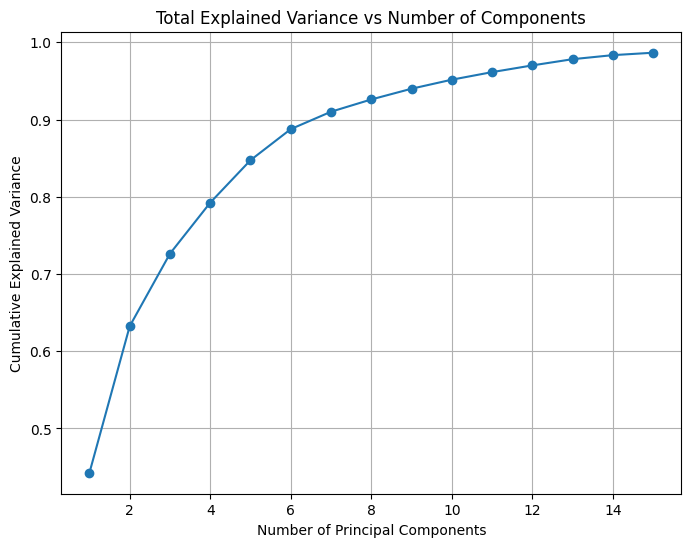

In [29]:
plt.figure(figsize=(8,6))

plt.plot(
    range(1, len(cumulative_variance_full) + 1),
    cumulative_variance_full,
    marker="o"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Total Explained Variance vs Number of Components")
plt.grid(True)
plt.show()

In [30]:
# Przed użyciem RFE dane należy standaryzować.

# breast_cancer_X
# breast_cancer_y

In [31]:
breast_cancer_rfe_pipeline = Pipeline([
    (
        'scaler',
        StandardScaler()
    ),
    (
        'rfe',
        RFE(
            estimator=LogisticRegression(n_jobs=-1),
            n_features_to_select=15
        )
    )
])

breast_cancer_X_transformed = breast_cancer_rfe_pipeline.fit_transform(breast_cancer_X, breast_cancer_y)

selected_columns = breast_cancer_X.columns[
    breast_cancer_rfe_pipeline.named_steps['rfe'].support_
]
breast_cancer_df_transformed = pd.DataFrame(breast_cancer_X_transformed, columns=selected_columns)
breast_cancer_df_transformed = pd.concat([breast_cancer_df_transformed, breast_cancer_y], axis=1)

In [32]:
removed_columns = breast_cancer_X.columns[
    ~breast_cancer_rfe_pipeline.named_steps['rfe'].support_
]
removed_columns

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean smoothness',
       'mean concavity', 'mean symmetry', 'mean fractal dimension',
       'texture error', 'smoothness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst compactness', 'worst fractal dimension'],
      dtype='object')

In [33]:
selected_columns

Index(['mean area', 'mean compactness', 'mean concave points', 'radius error',
       'perimeter error', 'area error', 'compactness error', 'worst radius',
       'worst texture', 'worst perimeter', 'worst area', 'worst smoothness',
       'worst concavity', 'worst concave points', 'worst symmetry'],
      dtype='object')

In [34]:
pca = PCA(n_components=15)
pca.fit_transform(breast_cancer_X_transformed)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

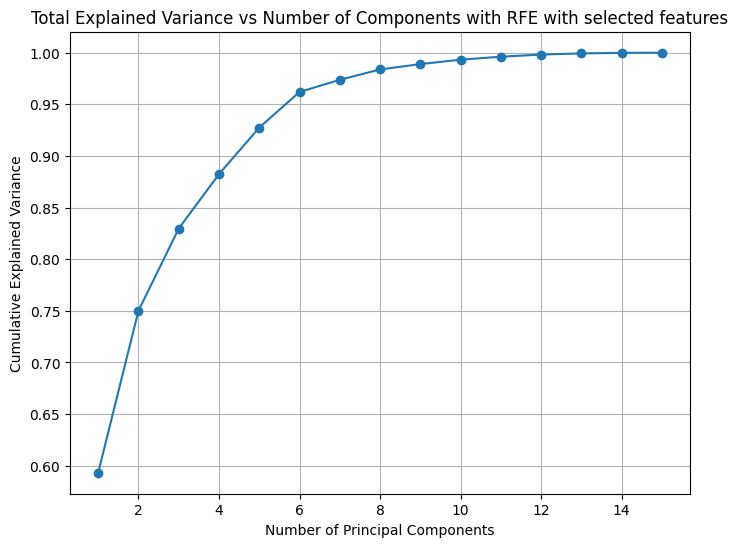

In [35]:
plt.figure(figsize=(8,6))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Total Explained Variance vs Number of Components with RFE with selected features")
plt.grid(True)
plt.show()

In [36]:
breast_cancer_X_transformed = breast_cancer_X[removed_columns]
breast_cancer_X_transformed = StandardScaler().fit_transform(breast_cancer_X_transformed)
breast_cancer_X_transformed = pd.DataFrame(breast_cancer_X_transformed, columns=removed_columns)

pca = PCA(n_components=15)
pca.fit_transform(breast_cancer_X_transformed)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

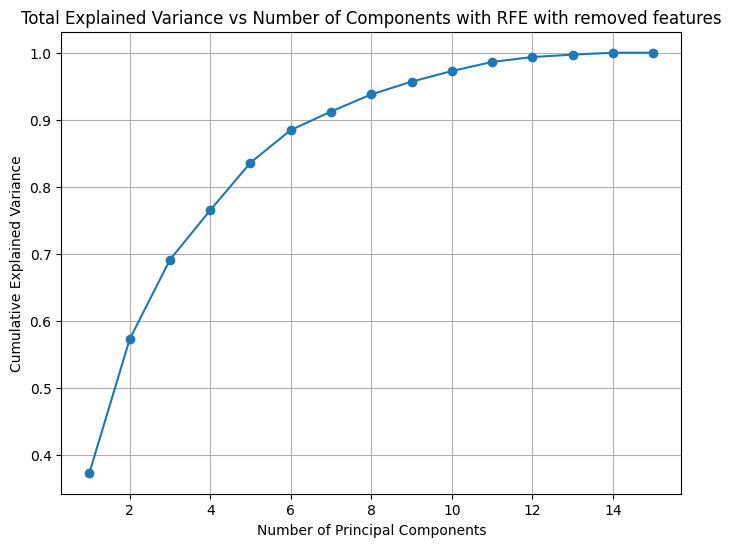

In [37]:
plt.figure(figsize=(8,6))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Total Explained Variance vs Number of Components with RFE with removed features")
plt.grid(True)
plt.show()

In [38]:
# Narysowałem trzy wykresy PCA – dla pełnych danych, dla 15 najlepszych cech oraz dla 15 najgorszych cech.
# Wyniki pokazują, że dla zestawu '15 najlepszych' potrzeba mniejszej liczby komponentów PCA,
# aby osiągnąć ten sam poziom skumulowanej wyjaśnionej wariancji, co oznacza, że informacja jest tam bardziej skoncentrowana.

# Wykres dla zestawu '15 najgorszych' jest gorszy, niż ten dla pełnego zestawu danych (ze wszystkimi kolumnami)

# Exercise 2: Kernel PCA

In [42]:
# Zacznijmy od początkowych, ale wystandaryzowanych danych:

breast_cancer_X_transformed = StandardScaler().fit_transform(breast_cancer_X)
breast_cancer_X_transformed = pd.DataFrame(breast_cancer_X_transformed, columns=breast_cancer_X.columns)
breast_cancer_X_transformed

breast_cancer_df_transformed = pd.concat([breast_cancer_X_transformed, breast_cancer_y], axis=1)
breast_cancer_df_transformed

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015,benign
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190,benign
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391,benign
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010,benign
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100,benign
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,2.110995,0.721473,2.060786,2.343856,1.041842,0.219060,1.947285,2.320965,-0.312589,-0.931027,...,0.117700,1.752563,2.015301,0.378365,-0.273318,0.664512,1.629151,-1.360158,-0.709091,benign
565,1.704854,2.085134,1.615931,1.723842,0.102458,-0.017833,0.693043,1.263669,-0.217664,-1.058611,...,2.047399,1.421940,1.494959,-0.691230,-0.394820,0.236573,0.733827,-0.531855,-0.973978,benign
566,0.702284,2.045574,0.672676,0.577953,-0.840484,-0.038680,0.046588,0.105777,-0.809117,-0.895587,...,1.374854,0.579001,0.427906,-0.809587,0.350735,0.326767,0.414069,-1.104549,-0.318409,benign
567,1.838341,2.336457,1.982524,1.735218,1.525767,3.272144,3.296944,2.658866,2.137194,1.043695,...,2.237926,2.303601,1.653171,1.430427,3.904848,3.197605,2.289985,1.919083,2.219635,benign


In [40]:
breast_cancer_X_transformed.columns

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension'],
      dtype='object')

In [48]:
breast_cancer_df_transformed['target'].cat.categories

Index(['benign', 'malignant'], dtype='object')

<Figure size 1400x1200 with 0 Axes>

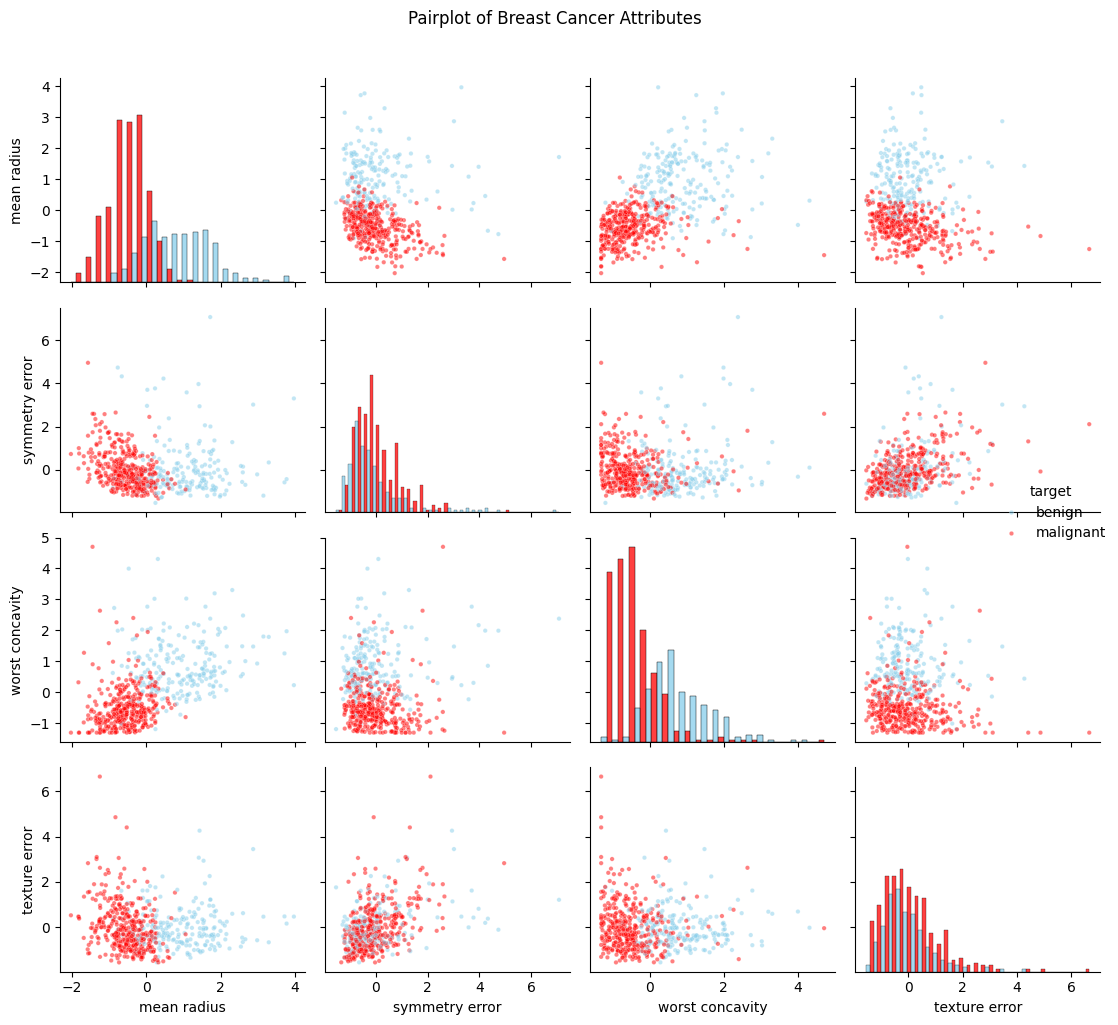

In [51]:
subset_attributes = ['mean radius', 'symmetry error', 'worst concavity', 'texture error']

plt.figure(figsize=(14,12))

sns.pairplot(breast_cancer_df_transformed[subset_attributes + ['target']], hue='target', diag_kind='hist', palette={'benign':'skyblue', 'malignant': 'red'}, diag_kws={'multiple': 'dodge'}, plot_kws={'alpha':0.5, 's':10})
plt.suptitle('Pairplot of Breast Cancer Attributes', y=1.02)

plt.tight_layout()
plt.show()

In [117]:
import plotly.graph_objects as go
import plotly.io as pio
from plotly.offline import init_notebook_mode, iplot

init_notebook_mode(connected=True)
pio.renderers.default = "notebook"

def plot_3d_plotly_scatter(X, y):
    X = np.asarray(X)
    y = np.asarray(y)

    classes = np.unique(y)
    traces = []

    for i, cls in enumerate(classes):
        class_indices = y == cls

        trace = go.Scatter3d(
            x=X[class_indices, 0],
            y=X[class_indices, 1],
            z=X[class_indices, 2],
            mode='markers',
            name=str(cls),
            marker=dict(
                size=4,
                color=i,
                colorscale='Jet',
                opacity=0.8,
                line=dict(
                    color='rgb(204,204,204)',
                    width=1
                )
            )
        )

        traces.append(trace)

    layout = go.Layout(
        margin=dict(l=0, r=0, b=0, t=0),
        scene=dict(
            xaxis_title='PC 1',
            yaxis_title='PC 2',
            zaxis_title='PC 3'
        )
    )

    fig = go.Figure(data=traces, layout=layout)
    iplot(fig)
#

def plot_2d(X, y, class_color_mapper):
    X = np.asarray(X)
    y = np.asarray(y)

    classes = np.unique(y)

    for i, cls in enumerate(classes):
        class_indices = y == cls
        color = class_color_mapper(cls)

        plt.scatter(
            X[class_indices, 0],
            X[class_indices, 1],
            s=10,
            alpha=0.7,
            c=color
        )

    plt.show()
#

In [72]:
breast_cancer_y.unique()

['benign', 'malignant']
Categories (2, object): ['benign', 'malignant']

In [77]:
breast_cancer_y.map({'malignant':1, 'benign':0}).astype(np.float32)

0      0.0
1      0.0
2      0.0
3      0.0
4      0.0
      ... 
564    0.0
565    0.0
566    0.0
567    0.0
568    1.0
Name: target, Length: 569, dtype: float32

<Axes: xlabel='target'>

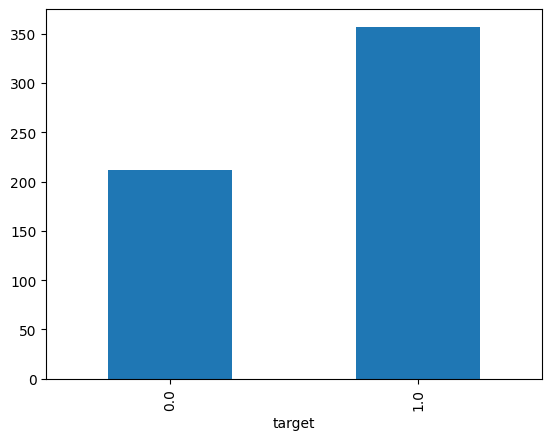

In [87]:
breast_cancer_y.map({'malignant':1, 'benign':0}).astype(np.float32).value_counts().sort_index().plot(kind="bar")

In [89]:
from sklearn.decomposition import KernelPCA

kernel_pca = KernelPCA(
    kernel='rbf',
    gamma=0.15,
    n_components=3
)

breast_cancer_X_kernel_pca = kernel_pca.fit_transform(breast_cancer_X_transformed)

plot_3d_plotly_scatter(breast_cancer_X_kernel_pca, breast_cancer_y)

In [105]:
from sklearn.decomposition import KernelPCA

kernel_pca = KernelPCA(
    kernel='poly',
    gamma=0.000000001,
    n_components=3
)

breast_cancer_X_kernel_pca = kernel_pca.fit_transform(breast_cancer_X_transformed)

plot_3d_plotly_scatter(breast_cancer_X_kernel_pca, breast_cancer_y)

In [97]:
from sklearn.decomposition import KernelPCA

kernel_pca = KernelPCA(
    kernel='sigmoid',
    gamma=0.000000001,
    n_components=3
)

breast_cancer_X_kernel_pca = kernel_pca.fit_transform(breast_cancer_X_transformed)

plot_3d_plotly_scatter(breast_cancer_X_kernel_pca, breast_cancer_y)

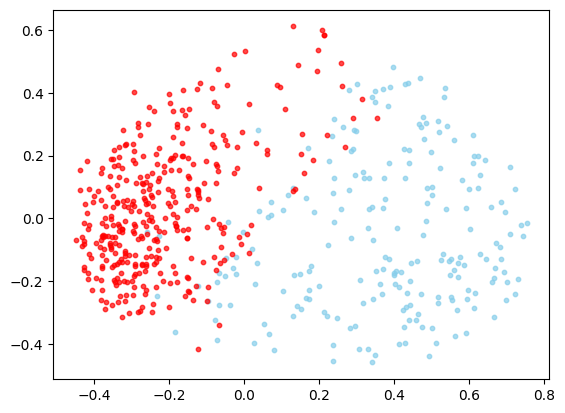

In [127]:
from sklearn.decomposition import KernelPCA

kernel_pca = KernelPCA(
    kernel='rbf',
    gamma=0.01,
    n_components=2
)

breast_cancer_X_kernel_pca = kernel_pca.fit_transform(breast_cancer_X_transformed)

plot_2d(
    breast_cancer_X_kernel_pca,
    breast_cancer_y,
    lambda cls: 'red' if cls == 'malignant' else 'skyblue'
)

In [136]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

pipe = Pipeline([
    ('kpca', KernelPCA(n_components=2)),
    ('clf', LogisticRegression(max_iter=500))
])

param_grid = [
    {
        'kpca__kernel': ['rbf'],
        'kpca__gamma': [0.001, 0.01, 0.1, 1, 5, 10],
    },

    {
        'kpca__kernel': ['poly'],
        'kpca__gamma': [0.001, 0.01, 0.1, 1, 5],
        'kpca__degree': [2, 3, 4],
        'kpca__coef0': [0, 1],
    },

    {
        'kpca__kernel': ['sigmoid'],
        'kpca__gamma': [0.001, 0.01, 0.1, 1, 5],
        'kpca__coef0': [0, 1],
    },

    {
        'kpca__kernel': ['cosine'],
    }
]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    pipe,
    param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(breast_cancer_X_transformed, breast_cancer_y)

print('Best parameters:', grid.best_params_)
print('Best CV score:', grid.best_score_)

Best parameters: {'kpca__coef0': 0, 'kpca__gamma': 0.1, 'kpca__kernel': 'sigmoid'}
Best CV score: 0.9508461419034312


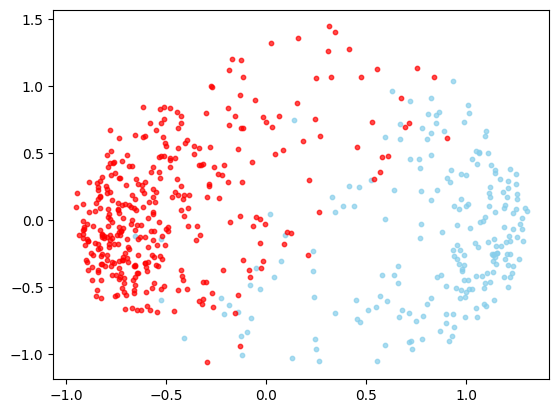

In [137]:
plot_2d(
    grid.best_estimator_.named_steps['kpca'].transform(breast_cancer_X_transformed),
    breast_cancer_y,
    lambda cls: 'red' if cls == 'malignant' else 'skyblue'
)